In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

conn = sqlite3.connect("../data/checking-logs.sqlite")

In [2]:
# Загрузка данных
df = pd.read_sql_query("SELECT uid, timestamp FROM checker WHERE uid LIKE 'user_%'", conn)

# Преобразование формата времени
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['weekday'] = df['timestamp'].dt.day_name() 
df['hour'] = df['timestamp'].dt.hour

In [3]:
df

,uid,timestamp,weekday,hour
0,user_4,2020-04-17 05:19:02.744528,Friday,5
1,user_4,2020-04-17 05:22:35.249331,Friday,5
2,user_4,2020-04-17 05:22:45.549397,Friday,5
3,user_4,2020-04-17 05:34:14.691200,Friday,5
4,user_4,2020-04-17 05:34:24.422370,Friday,5
...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,Thursday,20
3203,user_1,2020-05-21 20:22:41.785725,Thursday,20
3204,user_1,2020-05-21 20:22:41.877806,Thursday,20
3205,user_1,2020-05-21 20:37:00.129678,Thursday,20


In [4]:
# Подсчёт коммитов по дням недели и часам
heatmap_weekdays = df.groupby(['uid', 'weekday']).size().unstack(fill_value=0)
heatmap_hours = df.groupby(['uid', 'hour']).size().unstack(fill_value=0)

In [5]:
# Сортировка пользователей по количеству коммитов
heatmap_weekdays = heatmap_weekdays.loc[heatmap_weekdays.sum(axis=1).sort_values(ascending=False).index]
heatmap_hours = heatmap_hours.loc[heatmap_hours.sum(axis=1).sort_values(ascending=False).index]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3207 entries, 0 to 3206
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   uid        3207 non-null   object        
 1   timestamp  3207 non-null   datetime64[ns]
 2   weekday    3207 non-null   object        
 3   hour       3207 non-null   int32         
dtypes: datetime64[ns](1), int32(1), object(2)
memory usage: 87.8+ KB


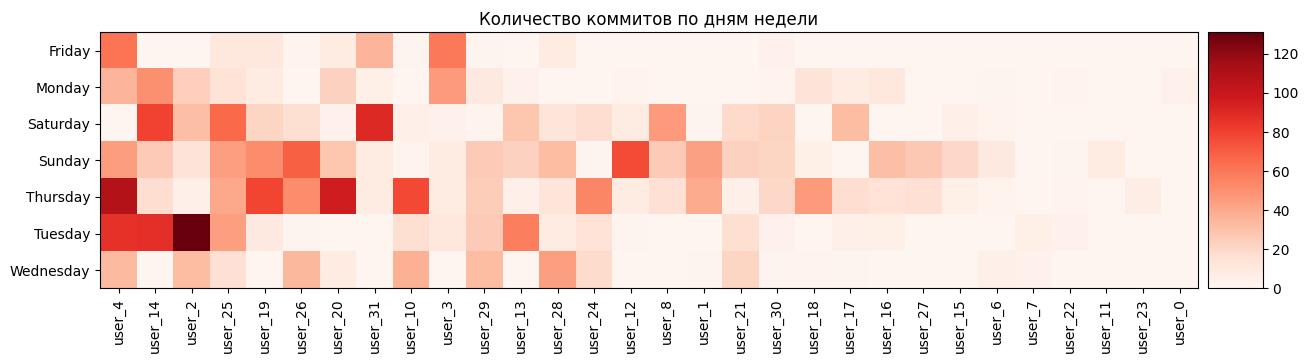

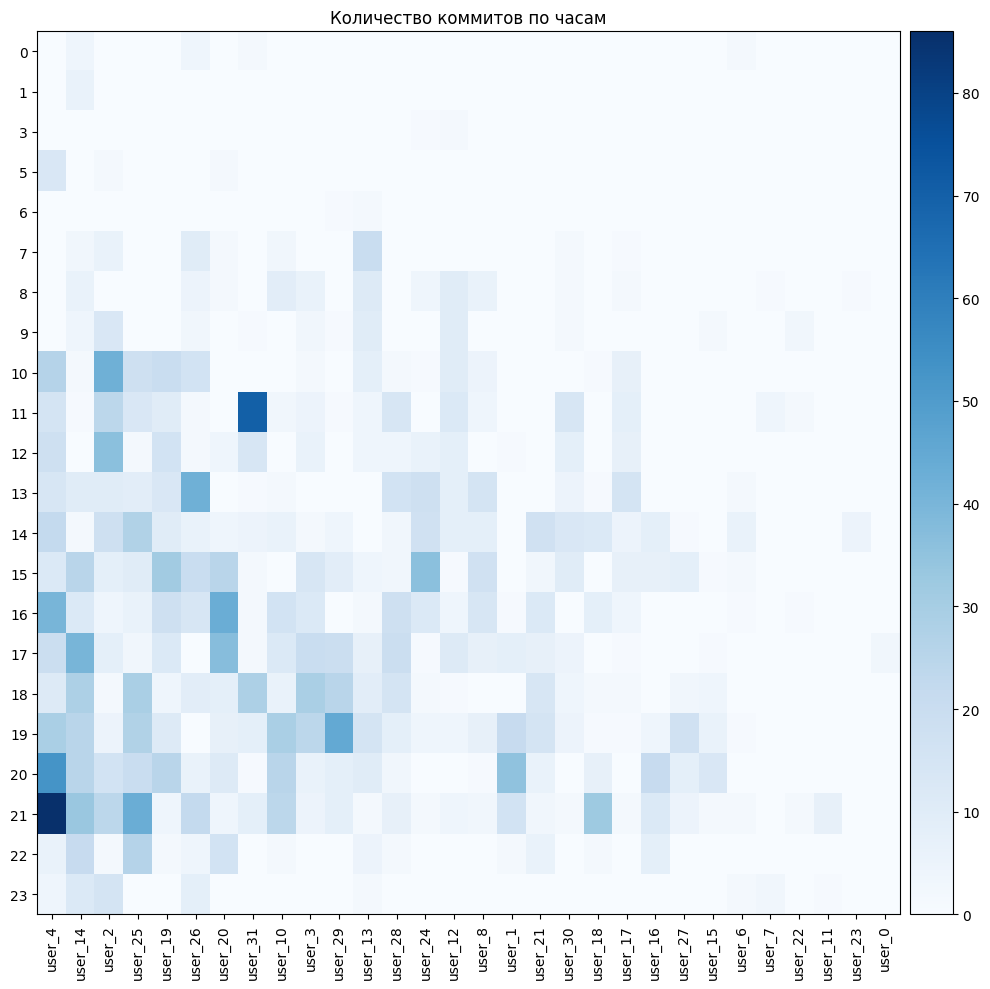

In [7]:
# График 1: Коммиты по дням недели 
fig, ax1 = plt.subplots(figsize=(15, 8)) 
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)

im1 = ax1.imshow(heatmap_weekdays.T, cmap="Reds") 
plt.colorbar(im1, cax=cax1)
ax1.set_yticks(range(len(heatmap_weekdays.columns)))
ax1.set_yticklabels(heatmap_weekdays.columns)
ax1.set_xticks(range(len(heatmap_weekdays.index)))
ax1.set_xticklabels(heatmap_weekdays.index, rotation=90)
ax1.set_title("Количество коммитов по дням недели")

# График 2: Коммиты по часам 
fig, ax2 = plt.subplots(figsize=(10, 10))  
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)

im2 = ax2.imshow(heatmap_hours.T, cmap="Blues", aspect="auto")  
plt.colorbar(im2, cax=cax2)
ax2.set_yticks(range(len(heatmap_hours.columns)))
ax2.set_yticklabels(heatmap_hours.columns)
ax2.set_xticks(range(len(heatmap_hours.index)))
ax2.set_xticklabels(heatmap_hours.index, rotation=90)
ax2.set_title("Количество коммитов по часам")

plt.tight_layout()
plt.show()